# Autoencoders and VAEs

## Start with the problem: learn a representation that can reconstruct an observation

Imagine describing a collection of measurements with a compact set of features and then reconstructing the original measurements from those features. An **autoencoder** learns two transformations: an encoder from an observation to a code, and a decoder from the code to a reconstruction.

A good reconstruction is useful evidence about retained information, but it does not establish that arbitrary codes decode to plausible observations. A **variational autoencoder (VAE)** makes the latent representation probabilistic and relates it to a prior distribution, enabling a defined latent sampling procedure.

This lesson follows reconstruction arithmetic, Gaussian latent sampling, the KL penalty, gradients, and generation. The [code companion](38_Autoencoders_and_VAEs.ipynb) trains a small two-dimensional VAE-like system on locally generated Gaussian data.

Its latent width is two, equal to its input width, so this particular example is not a dimensionality-reduction bottleneck. It demonstrates probabilistic encoding, reconstruction, and prior sampling. [Generative Modeling Foundations](37_Generative_Modeling_Foundations_Notes.ipynb) explains why samples and distribution fidelity need more evidence than one attractive result.


## Separate a deterministic code from a latent distribution

| Model | Encoder produces | Decoder receives | Core teaching question |
| --- | --- | --- | --- |
| Plain autoencoder | A code $z=f(x)$ | That code | What information can reconstruct $x$? |
| VAE | Parameters of $q_\phi(z\mid x)$ | A sampled latent | Can reconstruction and a prior-compatible latent coexist? |

A deterministic autoencoder can use a narrower code, regularization, or corrupted inputs to encourage useful features. Width alone is not a semantic guarantee: even a compact representation can preserve patterns that do not help a downstream task.

A VAE specifies a prior $p(z)$, often standard normal, and an observation model $p_\theta(x\mid z)$. Its encoder approximates the posterior over latents for an observed input. The foundational variational and reparameterization approach is described in [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114).

The decoder's architecture and observation-loss assumptions determine what reconstruction means. A numerical measurement task and a categorical pixel task need not use the same likelihood or output activation.


## Follow encoding, sampling, decoding, and the objective

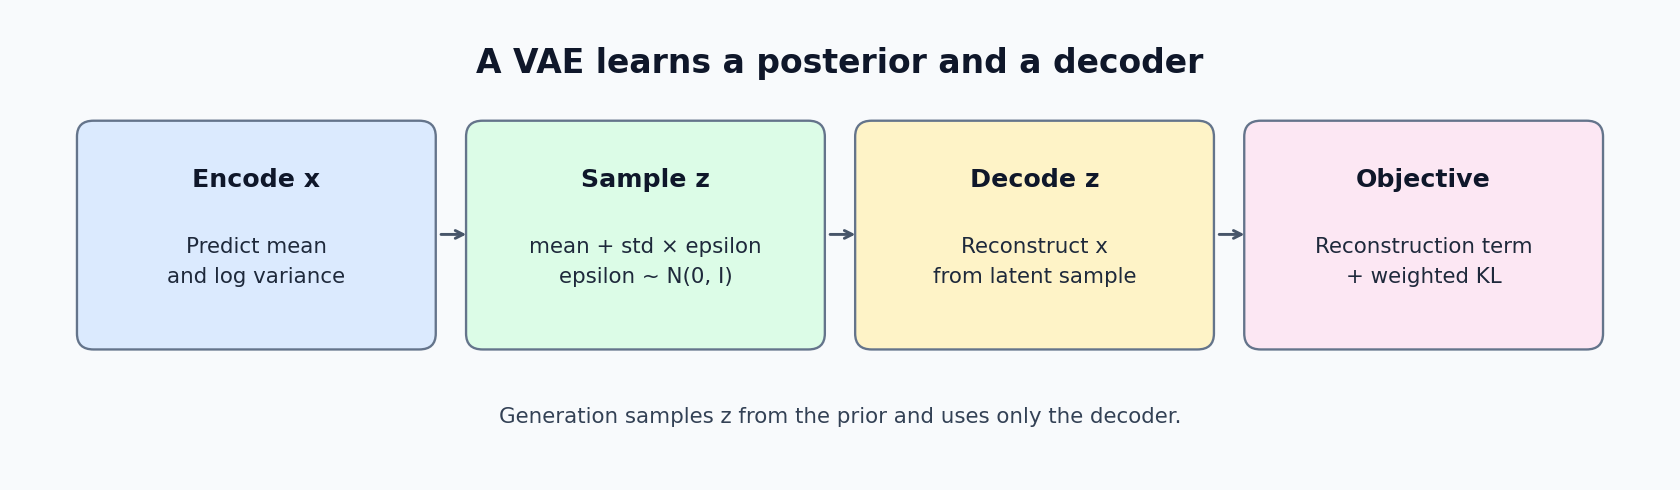

For observed $x$, the encoder produces mean $\mu(x)$ and log variance $\ell(x)$. Convert log variance to standard deviation, draw independent noise, and construct the latent:

$$\sigma=\exp(\ell/2),\qquad\epsilon\sim\mathcal N(0,I),\qquad z=\mu+\sigma\odot\epsilon.$$

The decoder maps $z$ to a reconstruction or parameters of an observation distribution. Training combines the reconstruction term with a prior-related regularizer.

| Symbol | Meaning |
| --- | --- |
| $q_\phi(z\mid x)$ | Encoder's approximate latent posterior |
| $p(z)$ | Chosen latent prior |
| $\mu,\ell$ | Mean and log-variance vectors |
| $\epsilon$ | Independent standard-normal draw |
| $z$ | Latent sample supplied to the decoder |
| $\hat x$ | Decoder's reconstruction vector in the companion |

Do not treat the mean, sampled latent, and reconstruction as interchangeable tensors just because they happen to share width two in this example.


## Calculate a reconstruction error by hand

Choose input $x=[1,0]$ and reconstruction $\hat x=[0.8,0.3]$. Mean squared error over the two coordinates is:

$$L_{rec}=\frac{(0.8-1)^2+(0.3-0)^2}{2}=0.065.$$

| Coordinate | Target | Reconstruction | Error | Squared error |
| --- | --- | --- | --- | --- |
| 0 | 1 | 0.8 | -0.2 | 0.04 |
| 1 | 0 | 0.3 | 0.3 | 0.09 |

The decoder is penalized for both missing part of the first value and adding an unwanted second value. Reconstruction accuracy does not automatically mean the code captures an interpretable concept.

A stochastic VAE reconstruction also depends on the sampled latent. Comparing a sampled reconstruction with a deterministic decoder output from the posterior mean answers different questions. Define which reconstruction policy is used for validation and visualization.

These are selected teaching values, not the companion's reported outputs. Its reconstruction loss averages over all batch elements and both coordinates.


## Convert log variance without confusing it with log standard deviation

A diagonal Gaussian uses independent latent coordinates conditional on $x$, with covariance entries $\sigma_j^2$. The encoder often predicts $\ell_j=\ln\sigma_j^2$ so its outputs need not be constrained to positive numbers.

| Coordinate | Mean $\mu$ | Variance | Log variance $\ell$ | Standard deviation |
| --- | --- | --- | --- | --- |
| 0 | 1 | 0.25 | -1.386294 | 0.5 |
| 1 | -0.5 | 2.25 | 0.810930 | 1.5 |

Exponentiating log variance gives **variance**; exponentiating half of it gives standard deviation. Using $\exp(\ell)$ as the noise multiplier would produce the wrong spread.

The phrase diagonal Gaussian does not mean the full dataset has independent features or that all learned semantics are independent. It describes the chosen conditional latent distribution for each input. The decoder can mix latent coordinates nonlinearly.

The companion has separate linear heads for mean and log variance. Both receive the shared encoder's hidden features and both are adjusted during training.


## Sample a latent with every intermediate value visible

Use the selected parameters $\mu=[1,-0.5]$, $\sigma=[0.5,1.5]$, and selected standard-normal noise $\epsilon=[-1,2]$.

| Coordinate | Mean | Standard deviation | Noise | Scaled noise | Latent sample |
| --- | --- | --- | --- | --- | --- |
| 0 | 1 | 0.5 | -1 | -0.5 | 0.5 |
| 1 | -0.5 | 1.5 | 2 | 3 | 2.5 |

Thus $z=[0.5,2.5]$. Another draw from the same posterior generally gives another latent and possibly another reconstruction.

Conditional on the input, the expected latent is $\mu$ and its coordinate variances are $\sigma^2$. One draw does not itself need to resemble the mean or lie within one standard deviation.

The reparameterization places randomness in $\epsilon$ while leaving a differentiable transformation of learned parameters. It does not make the training deterministic or remove Monte Carlo variation. Holding a sampled $\epsilon$ fixed is useful when checking a local derivative numerically.


## See why the latent posterior and prior are different objects

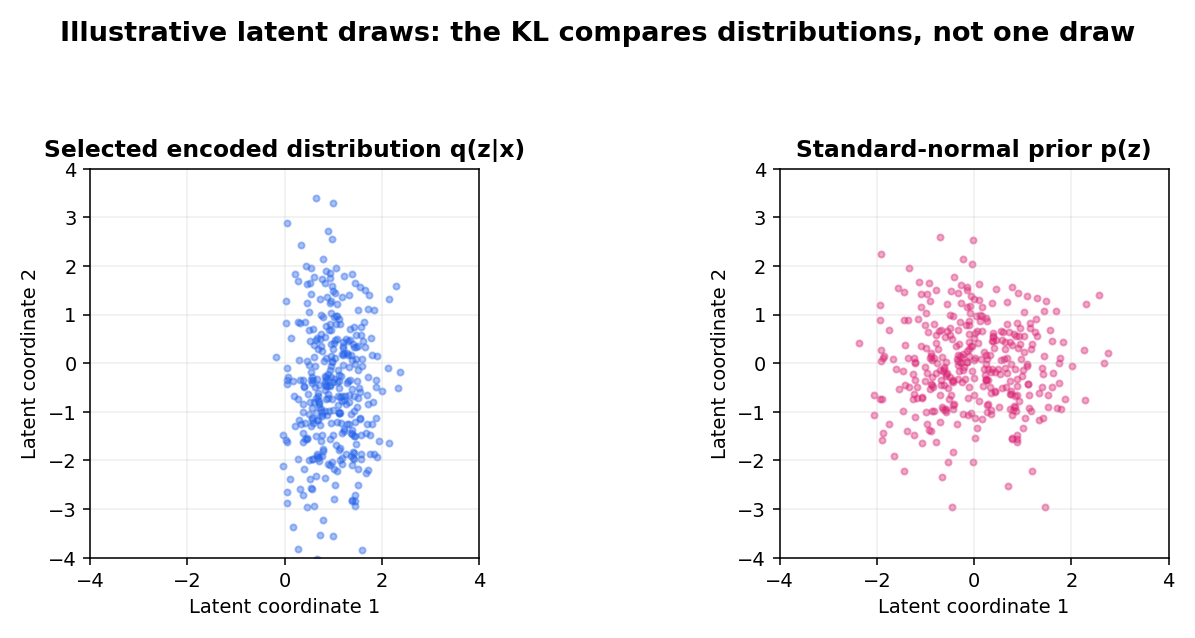

For the chosen input posterior, one coordinate is centered at one with spread 0.5 and the other at -0.5 with spread 1.5. The standard-normal prior instead has zero mean and unit variance in each coordinate.

These plotted clouds are illustrative draws from selected distributions, not trained encoder results. The KL term compares distributions, not the distance of one latent sample from the origin.

During reconstruction, $q(z\mid x)$ can depend on the observed input. During generation, there is no observed input to encode, so the sampler uses the chosen prior. Relating the encoded distributions to the prior helps make those two entry points more compatible.

It does not force every latent point to decode well or give each coordinate a human-defined meaning. Prior coverage and useful generated outputs still need to be evaluated.


## Calculate the diagonal Gaussian KL term

For $q=\mathcal N(\mu,\operatorname{diag}(\sigma^2))$ and $p=\mathcal N(0,I)$:

$$D_{KL}(q\Vert p)=\frac12\sum_j\left(\mu_j^2+\sigma_j^2-1-\ln\sigma_j^2\right).$$

Using the selected two-coordinate posterior:

| Coordinate | $\mu^2$ | $\sigma^2$ | $\ln\sigma^2$ | KL contribution |
| --- | --- | --- | --- | --- |
| 0 | 1 | 0.25 | -1.386294 | 0.818147 |
| 1 | 0.25 | 2.25 | 0.810930 | 0.344535 |

The sum is approximately 1.162682. A zero-mean, unit-variance posterior gives zero KL to this prior. Changing either mean or variance generally increases it.

This direction is $D_{KL}(q\Vert p)$, not a symmetric distance. The stated formula depends on the diagonal-Gaussian posterior and standard-normal prior; another choice can require another calculation.

The companion sums contributions across latent coordinates and then averages across examples. Its reconstruction term instead averages over both examples and input coordinates, so the two reductions matter when interpreting their relative weights.


## Relate the variational objective to the companion's surrogate

A negative evidence lower bound can be written as:

$$-ELBO=\mathbb E_{q_\phi(z\mid x)}[-\ln p_\theta(x\mid z)]+D_{KL}(q_\phi(z\mid x)\Vert p(z)).$$

For a Gaussian observation model with fixed variance, negative log likelihood contains a scaled squared reconstruction error plus constants. The scaling depends on that observation variance and the reduction over coordinates.

The companion uses the explicit weighted loss:

$$L=L_{MSE}+0.05\,L_{KL}.$$

For reconstruction MSE 0.065 and the selected KL 1.162682, this is about 0.123134. This is the companion's VAE-style training surrogate; do not silently identify its unscaled MSE and KL weight with every probabilistic model's exact negative ELBO.

| Choice | Effect |
| --- | --- |
| Reconstruction reduction | Changes error weighting and scale |
| KL reduction | Changes latent-dimension/batch weighting |
| KL coefficient | Changes the balance between terms |
| Observation distribution | Changes the meaning of reconstruction likelihood |

An informative comparison records these choices rather than only stating that two experiments “use a VAE loss.”


## Follow gradients through reconstruction and latent parameters

For the two-coordinate reconstruction MSE, the derivatives into $\hat x$ are $[-0.2,0.3]$. Treat the reconstructed entries as adjustable decoder biases for an isolated example. At learning rate 0.1, they move to $[0.82,0.27]$, lowering MSE to 0.05265.

For the KL term, using log variance $\ell$:

$$\frac{\partial KL}{\partial\mu_j}=\mu_j,\qquad\frac{\partial KL}{\partial\ell_j}=\frac12(e^{\ell_j}-1).$$

The selected unweighted gradients are $[1,-0.5]$ for mean and $[-0.375,0.625]$ for log variance. The companion's coefficient multiplies these contributions by 0.05.

The reconstruction path also contributes to mean and log-variance gradients through the sample:

$$\frac{\partial z_j}{\partial\mu_j}=1,\qquad\frac{\partial z_j}{\partial\ell_j}=\frac12\sigma_j\epsilon_j.$$

For the selected noise, the latter derivatives are $[-0.25,1.5]$. Full training combines reconstruction-path and KL gradients, rather than moving latent parameters only toward the prior. The decoder-bias update above isolates reconstruction; it is not a complete update to every VAE parameter.


## Trace the exact companion network

The companion generates 256 two-dimensional observations with mean $[1,-1]$ and coordinate standard deviation 0.7. Its encoder maps two inputs to sixteen ReLU features; two heads produce two means and two log variances.

| Module | Output shape for the training batch | Parameters |
| --- | --- | --- |
| Encoder linear $2\to16$ | $(256,16)$ | 48 |
| Mean head $16\to2$ | $(256,2)$ | 34 |
| Log-variance head $16\to2$ | $(256,2)$ | 34 |
| Latent sample | $(256,2)$ | None |
| Decoder linear $2\to16$ | $(256,16)$ | 48 |
| Decoder linear $16\to2$ | $(256,2)$ | 34 |

The model has 198 parameters. It takes 120 full-batch Adam steps at learning rate 0.01. Fresh latent noise is drawn in each forward pass, so the stochastic reconstruction can change even when the data batch is unchanged.

No held-out reconstruction or generation assessment is included. The printed losses describe this run's objective, while the generated-shape assertion checks an interface rather than a distributional match.


## Generate from the prior rather than encoding an observed input

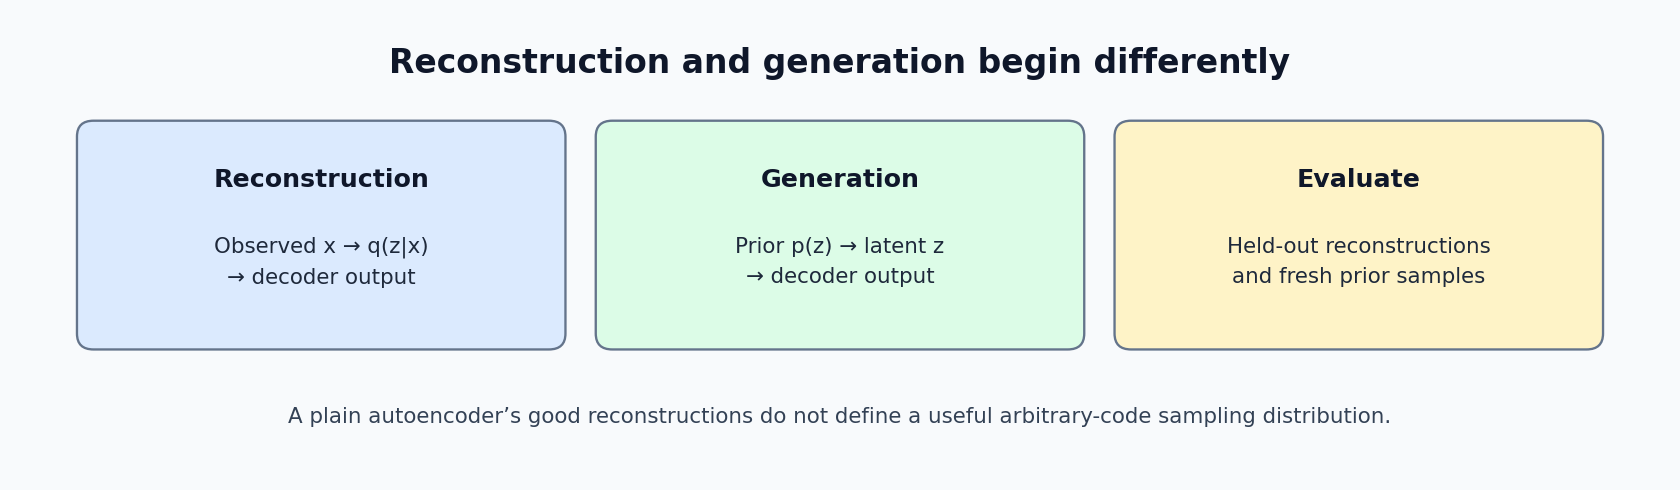

The companion generates eight outputs by passing eight standard-normal two-dimensional draws directly to the decoder. It does not run the encoder for this operation.

| Operation | Latent source | What it assesses |
| --- | --- | --- |
| Sampled reconstruction | $q(z\mid x)$ for observed $x$ | Retention under posterior sampling |
| Posterior-mean reconstruction | Encoder mean | Deterministic code readout |
| Prior generation | $p(z)$ | Behavior away from a supplied observation |

Its decoder returns numerical vectors and adds no separate observation-noise draw. In a full probabilistic decoder, generating from $p_\theta(x\mid z)$ can additionally require sampling that observation distribution.

Compare generated means, spread, and shape against independent target data when studying this numerical example. Good reconstruction of training points and a finite loss do not establish that prior samples follow the target Gaussian or that the latent encodes a useful downstream representation.


## Understand the reconstruction–regularization tradeoff

A weak prior penalty can let encoded latents occupy narrow or displaced regions, so random prior draws may visit regions the decoder has used poorly. A strong penalty can reduce input-specific latent information, harming reconstruction or leading the decoder to ignore the code.

**Posterior collapse** refers to a situation where the approximate posterior becomes close to the prior and the model makes little useful use of input-specific latent information. A small KL is not, by itself, proof that the representation is successfully organized.

| Observation | Question to investigate |
| --- | --- |
| Good reconstruction, poor prior outputs | Does the prior cover useful encoded regions? |
| Very small KL and weak input dependence | Is the latent being ignored? |
| Large KL | Are means/spreads far from the prior? |
| Stochastic reconstructions vary strongly | Is posterior spread appropriate for the task? |

Latent interpolation can be visually interesting but does not guarantee semantic control or correct probabilities. Evaluate reconstruction, prior generation, and representation usefulness as separate goals.


## Diagnose the objective before judging the samples

| Mistake | Consequence | Check |
| --- | --- | --- |
| Use $\exp(\ell)$ as standard deviation | Wrong posterior spread | Half-log-variance conversion |
| Change loss reductions without adjusting the comparison | Different relative weighting | Batch and coordinate axes |
| Call posterior draws prior generation | Wrong sampling interpretation | Entry point to the model |
| Assume latent width must be smaller here | Misdescribe this companion | Input and latent widths are both two |
| Interpret finite loss as learned distribution quality | Unsupported conclusion | Independent reconstruction and sample checks |

The companion demonstrates learned parameters and prior-driven decoder outputs, unlike the fixed sampler in lesson 37. It still lacks a held-out distributional evaluation. These notes' hand calculations establish mechanics and gradients without inventing a trained performance claim.


## Practice the latent distribution and retain the two entry points

1. If log variance is $\ln4$, what standard deviation multiplies the noise?
2. With mean one, standard deviation two, and selected noise -0.5, what latent sample results?
3. What KL does $\mathcal N(0,1)$ have to the standard-normal prior?
4. Does reconstruction start from the same distribution as unconditional prior generation?
5. How many learned parameters are in the companion model?

**Answers.** Standard deviation is two. The sample is $1+2(-0.5)=0$. The KL is zero. Reconstruction uses an input-conditioned posterior while generation uses the prior. The companion has 198 parameters.

**Remember:** an autoencoder learns to reconstruct; a VAE adds a probabilistic code and a prior-related objective. Reparameterization supplies a differentiable sample path, while loss scaling and the generation entry point determine what the experiment actually means.

Continue with [GANs](39_GANs_Notes.ipynb), where a learned opponent supplies the generation training signal.
